# Introduction

Mathematical models of the epidemiological effects of malaria vaccines demonstrate that vaccine efficacy and cases averted depend on transmission intensity (e.g., @penny_public_2016). In addition, our modelling demonstrates that for the R21 vaccine, long-term averted deaths and death efficacy drop precipitously below about three blood infections per year and go negative below about 1.5 infections per year. The decision of which vaccines to deploy in a population should therefore be informed by the prevailing blood infection rate. It is of interest, therefore, to understand the worldwide distribution of blood infection rates in children where *P. falciparum* malaria exists.

Blood infection rate, however, has not been used as a measure of transmission intensity in the malaria epidemiological literature due to the difficulty of measuring independent blood infections particularly in high transmission settings. Instead, the standard measures of transmission intensity are the entomological inoculation rate (EIR) and the parasite rate (*Pf*PR~2-10~) [@smith_standardizing_2007]. EIR is typically measured as the average number of infectious bites per person per year - which is estimated by multiplying the human biting rate (how often mosquitoes bite people) by the sporozoite rate (the percentage of those mosquitoes carrying infectious malaria parasites). *Pf*PR~2-10~ is the proportion of two-to-ten year olds in a population with asexual *P. falciparum* parasites in their blood at a given point in time. These rates provide broad estimates of transmission intensity but imprecise estimates of average blood infection rates in a population. 

The key source of data on worldwide transmission intensity, as measured by *Pf*PR~2-10~, is the [Malaria Atlas Project](https://malariaatlas.org) (MAP, @hay_malaria_2006). MAP has collated *Pf*PR~2-10~ estimates in thousands of sites around the world over the last four decades — the majority in Africa. This survey data is used to infer the geo-spatial distribution of *Pf*PR~2-10~, which can be downloaded from the MAP website. 

Our aim here is to first construct distributions of *Pf*PR~2-10~ over two datasets: (i) the MAP survey data in Africa and (ii) the number of African children under ten years of age. 

To obtain the distribution of *Pf*PR~2-10~ over survey sites, we downloaded the survey data for *P. falciparum* by cloning the malaria-atlas-project github repository and running the following command in R: 

```r
getPR(species = "Pf")
```

To obtain the distribution of *Pf*PR~2-10~ over African children under ten we downloaded a raster of the geospatial distribution of *Pf*PR~2-10~ from [the MAP website](https://data.malariaatlas.org/). This map has a spatial resolution of 5km. And we downloaded the 2025 worldwide spatial distribution of people from WorldPop which has a spatial resolution of 1km [@bondarenko_spatial_2025].

Having constructed distributions of *Pf*PR~2-10~, we then convert them into distributions of blood infection rates. To achieve this we make use of two datasets that quantify the relationship between *Pf*PR~2-10~ and annual clinical episode rate in the under fives [@griffin_estimates_2014; @trape_rise_2014] and combine these with our model in which we quantify the relationship between annual clinical episode rate in the under fives with blood infection rate.

# Distribution of *Pf*PR~2-10~ over MAP surveys

In [3]:
#| output: false

import pickle
from Scripts import infection_rate

map = infection_rate.get_pfpr()
with open('Data/pfpr_0-9.pickle', 'rb') as file:
    count_mean_total_africa = pickle.load(file)[1]

@fig-pfpr_distribution_surveys shows a the distributions of *Pf*PR~2-10~ every five years from 1987 to 2022 [@hay_malaria_2006]. The distribution of *Pf*PR~2-10~ has remained relatively stable over 35 years of survey data. For our analysis we chose the most recent survey at each site from 2020 onwards (*n* = 2757 sites). The distribution of these sites is represented by the thick black line.

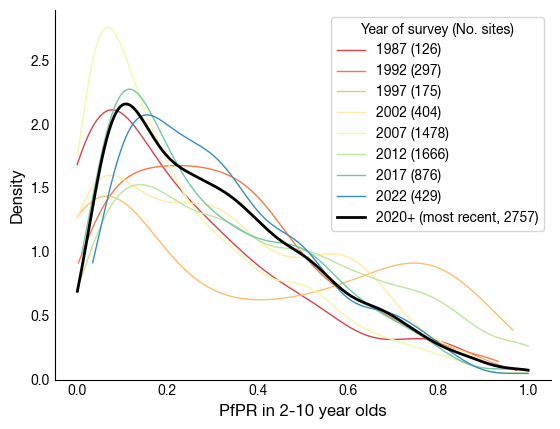

In [2]:
#| label: fig-pfpr_distribution_surveys
#| fig-cap: "Kernel density estimation plots of *Pf*PR~2-10~ survey data from the Malaria Atlas Project. Coloured lines are data from the indicated single years. The thick black line is the most recent survey at each site from 2020 onwards."

fig, ax = infection_rate.distribution_over_surveys(map)

# Distribution of *Pf*PR~2-10~ over African children under ten

## Geospatial distribution of *Pf*PR~2-10~

The geospatial distribution of *Pf*PR~2-10~ is shown in @fig-pr_geospatial where higher *Pf*PR~2-10~ is represented by brighter red.

:::{#fig-pr_geospatial}
![](Figures/pr_geo_dist.png){width=100%}

Geospatial distribution of posterior mean estimates of *Pf*PR~2-10~ downloaded from the Malaria Atlas Project. Resolution is 5km. Brighter red denotes higher *Pf*PR~2-10~.
:::


## Geospatial distribution of children under ten

The geospatial distribution of children under ten is shown in @fig-children_geospatial as green pixels.

:::{#fig-children_geospatial}
![](Figures/children_geo_dist.png){width=100%}

Geospatial distribution of children under ten in 1km^2^ pixels downloaded from WorldPop.
:::

For each 1km^2^ pixel containing at least one child under ten years of age we extracted the corresponding value of *Pf*PR~2-10~ if its value was above 0.1% and we extracted the number of children under 1, between 1-4 years old and between 5-9 years old. The code can be found in [geotiff.ipynb](geotiff.ipynb).

[@fig-pfpr_distribution_children]A shows the distribution over the whole world (393m children under ten) and over Africa-alone (351m children under ten). The main difference is the peak at very low transmission due to South East Asia and South America. In Africa, there is a sharp peak at about 4% due to low transmission mainly in East and Southern African. Panel B stratifies African children into the under 1s, 1-4 year olds and 5-9 year olds. There is little difference in the shapes of the distributions, but they vary in scale due to the different age ranges. 

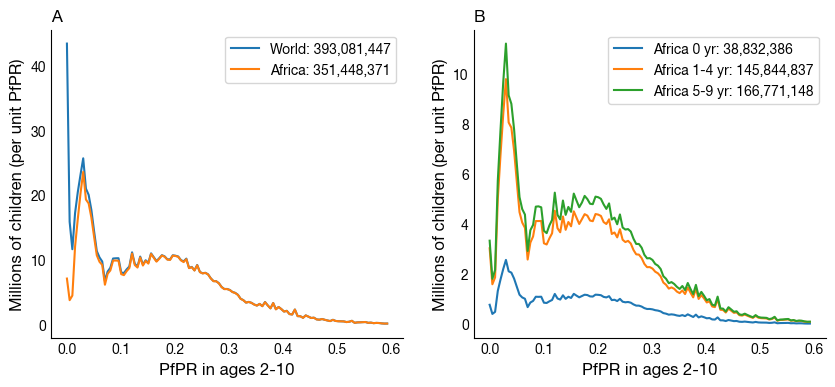

In [3]:
#| label: fig-pfpr_distribution_children
#| fig-cap: "Distributions of *Pf*PR~2-10~. A) whole world and Africa-alone. B) African children stratified by age."

fig, axs = infection_rate.distribution_over_children()

The shapes of the distributions differ between surveys [@fig-pfpr_distribution_surveys] and African children [@fig-pfpr_distribution_children]. In particular, the survey data peaks at around 10% and linearly decays to 0 at 100% whereas the African children data is bimodal with peaks around 4% and 20% and decays rapidly to zero above 60%. This may indicate a bias in surveys toward being conducted in sites with more prevalent malaria.    

# Distributions of blood infection rate

Having constructed distributions of *Pf*PR~2-10~, we now convert them into distributions of blood infection rates. To achieve this we first analyse two datasets that quantify the relationship between *Pf*PR~2-10~ and annual clinical episode rate in the under fives [@griffin_estimates_2014; @trape_rise_2014]. We then combine that analysis with simulations from our model in which we quantify the relationship between annual clinical episode rate in the under fives with blood infection rate.

## The relationship between *Pf*PR~2-10~ and clinical episode rate

@patil_defining_2009 have previously modelled the relationship between *Pf*PR~2-10~ and clinical episodes per 1,000 individuals per year. The relationship plateaus above a *Pf*PR~2-10~ of 20% in Africa and above 2% in Asia and the Americas (see Figure 5 of @patil_defining_2009). This means that this definition of clinical episode rate contains little information about *Pf*PR~2-10~ in the plateau. In turn, this prevents us from quantifying a relationship between *Pf*PR~2-10~ and blood infection rate.

A more information rich definition of clinical episode rate is the average annual clinical episodes in the under fives as these children are still developing clinical immunity so their clinical episode rate is more predictive of blood infection rate and, therefore, *Pf*PR~2-10~ than in the wider population. 

We found two datasets in the literature that contain this information: [@fig-log_clinical_pfpr]A below, reproduced from Figure 1 of @griffin_estimates_2014, shows the relationship between *Pf*PR~2-10~ and average annual clinical episodes in under fives in twenty three African sites. For the majority of these sites the definition of a clinical episode was fever and detectable parasites by microscopy; although a handful of sites used higher parasite thresholds. Case detection was variable: active or passive, daily or weekly. Five sites did not report *Pf*PR~2-10~; instead values were estimated from EIR [@griffin_estimates_2014]. 

[@fig-log_clinical_pfpr]A demonstrates that there is no one-to-one relationship between clinical episode rate and *Pf*PR~2-10~. But they are, at least, positively correlated and there is no obvious plateau.

A higher quality dataset, albeit from just one site — Dielmo in Senegal, is shown in [@fig-log_clinical_pfpr]B [@trape_rise_2014]. Clinical episodes were extracted from Figure 4A, and *Pf*PR~2-10~ was extracted from Figure S2A, of @trape_rise_2014. This site has been uninterruptedly followed since 1990 with a strict clinical surveillance program [@trape_1996; @trape_one_2024]. This includes daily home visits to each person and the 24-hour presence of medical teams in the village. 

The data show a clear positive relationship over a wider range of clinical episode rates than in panel A. This likely reflects the active, frequent and accurate diagnosis of clinical episodes in Dielmo. 

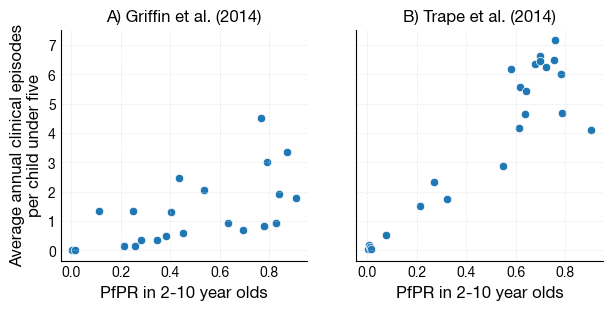

In [4]:
#| label: fig-log_clinical_pfpr
#| fig-cap: "Relationship between *Pf*PR~2-10~ and average annual clinical episodes per child in the under fives in A) 23 African sites (extracted from Figure 1 of @griffin_estimates_2014.) and B) Dielmo, Senegal (extracted from Figures 4A and S2A of @trape_rise_2014)."

data = infection_rate.get_pfpr_vs_clinical()
fig, ax = infection_rate.plot_pfpr_vs_clinical(data)

A linear regression of log-annual clinical episodes against log-*Pf*PR~2-10~ is shown in @fig-pfpr_clinical for both datasets. (Logs were taken to mitigate against heteroscedasticity.) The regression parameters are given in @tbl-regression. 

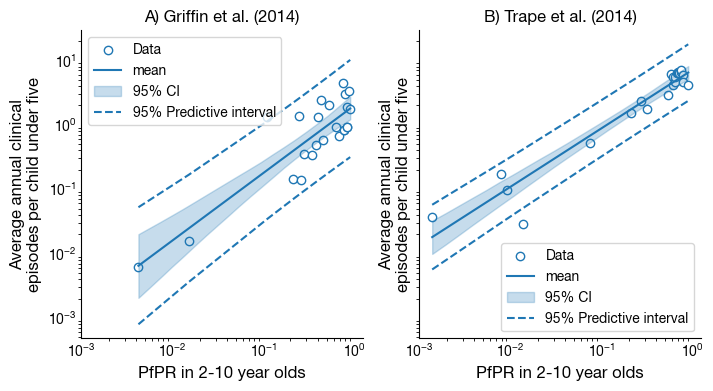

In [5]:
#| label: fig-pfpr_clinical
#| fig-cap: "Linear regression of log-annual clinical episodes against *Pf*PR~2-10~. Solid line: mean estimate, dashed lines: 95% predictive interval band estimated from the regression."

(griffin, trape), data = infection_rate.model_pfpr_clinical_relationship(data)
fig, axs = infection_rate.plot_model_pfpr_clinical_relationship((griffin, trape), data)

Parameter | @griffin_estimates_2014 | @trape_rise_2014
:-- | --: | --:
Intercept, $\beta_0$ | `{python} f'{griffin.params["Intercept"]:.2f}'` ± `{python} f'{griffin.bse["Intercept"]:.2f}'`$^{\dagger}$ | `{python} f'{trape.params["Intercept"]:.2f}'` ± `{python} f'{trape.bse["Intercept"]:.2f}'`
Slope, $\beta_1$ | `{python} f'{griffin.params["log_pfpr"]:.2f}'` ± `{python} f'{griffin.bse["log_pfpr"]:.2f}'` | `{python} f'{trape.params["log_pfpr"]:.2f}'` ± `{python} f'{trape.bse["log_pfpr"]:.2f}'`
$\sigma_c$ | `{python} f'{griffin.σ_c:.2f}'` | `{python} f'{trape.σ_c:.2f}'`

: Regression parameters. $^{\dagger}$Mean ± standard error {#tbl-regression}

The intercepts differ substantially between the two datasets, but the slopes are similar at about 1, suggesting that, on average, annual clinical episodes in under fives is proportional to *Pf*PR~2-10~.

$$\text{Mean average annual clinical episodes in the under fives} \approx 7\times \text{PfPR}_{2-10}$$

which is what we might expect from [@fig-log_clinical_pfpr]B.

The analysis also suggests that variability in average annual clinical episodes increases with *Pf*PR~2-10~. Of key interest is the predictive interval represented by the dashed lines in [@fig-pfpr_clinical]. This represents the width of the distribution of observable average annual clinical episodes in the under fives for a given *Pf*PR~2-10~. We will assume that this distribution is normal with standard deviation given by the average width of the predictive interval across observed *Pf*PR~2-10~ divided by $2\times 1.96$, which we call $\sigma_c$. 

Given the higher quality and smaller variability of the @trape_rise_2014 data, we only use its regression parameters in our further analysis.

## The relationship between annual clinical episodes in the under fives and blood infection rate

We can use our model to obtain the relationship between blood infection rate and average annual clinical episodes in the under fives. The sensitivity of this relationship to changes in model parameters is shown in [@fig-clinical_blood_rate]. 

This relationship should be sensitive to parameters that affect the risk of infection and the risk an infection becomes clinical in the first few years of life. This premise is born out in the analysis shown in [@fig-clinical_blood_rate]. The relationship is sensitive to the early life protection from infection parameters $\rho_\text{elp}$ and $\tau_\text{elp}$ and to the risk of clinical malaria on first infection $\rho_\text{clinical}$. 

The relationship is insensitive to changes in bite rate/susceptibility heterogeneity, $\beta$ and rate of decline in risk of clinical malaria with exposure $\delta_\text{clinical}$. The latter only affects the risk of clinical malaria later in life.

The relationship is also insensitive to changes in the half-maximum-risk of clinical malaria $\gamma_\text{clinical}$ below about ten blood infections per year. However, at higher infection rates the relationship is sensitive to this parameter because children reach this threshold earlier in life.

In our analysis below we will consider how this sensitivity to model parameters affects the distribution of blood infection rate across Africa.

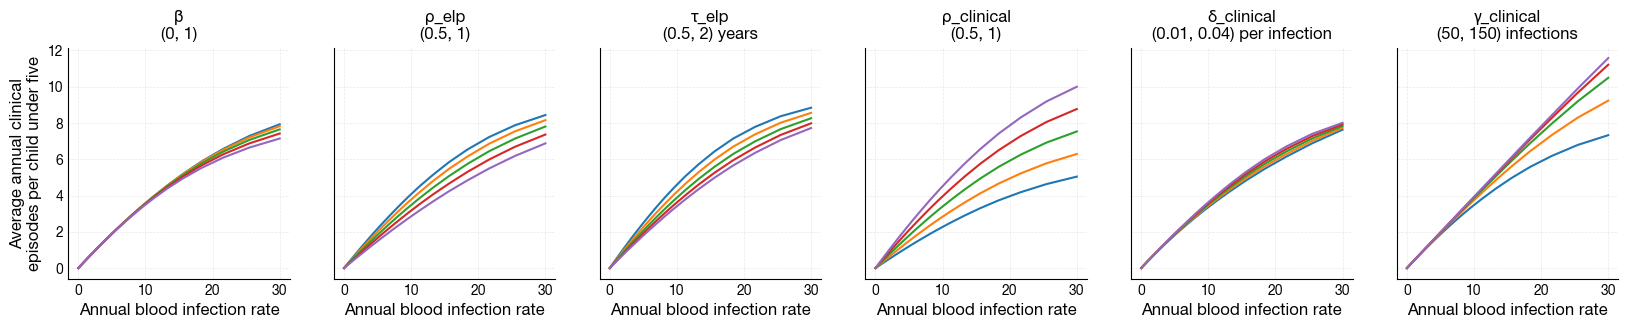

In [6]:
#| label: fig-clinical_blood_rate
#| fig-cap: "Sensitivity of the relationship between average annual clinical episodes in the under fives and blood infection rate to changes in model parameters."

fig, ax = infection_rate.infection_rate_vs_clinical_rate_sensitivity()

## Distributions of average annual clinical episodes in the under fives and blood infection rate

Here we detail how we convert the distributions of *Pf*PR~2-10~ — either over survey sites as shown in [@fig-pfpr_distribution_surveys] (black line) or over African children under ten as shown in [@fig-pfpr_distribution_children] (orange line) — to distributions of blood infection rate via distributions of average annual clinical episodes in the under fives.

First we propagate the uncertainties in the estimates of $\beta_0$ and $\beta_1$ and the variation in the *Pf*PR~2-10~-average annual clinical episodes in the under fives relationship, $\sigma_c$, into the distribution of average annual clinical episodes in the under fives. In the following all logs are in base 10.

Let $p(\log  c\ |\ \log r, \beta_0, \beta_1)$ be the distribution of log-average annual clinical episodes in the under fives ($\log  c$) for a given log-*Pf*PR~2-10~ ($\log  r$), $\beta_0$ and $\beta_1$ ([@fig-pfpr_clinical]). Let $p(\beta_0, \beta_1)$ be the joint distribution of $\beta_0$ and $\beta_1$ representing the uncertainty in their estimates. We assume that $p(\log  c\ |\ \log r, \beta_0, \beta_1)$ has a normal distribution with mean $\beta_0+\beta_1 \log r$ and variance $\sigma_c^2$. We assume $p(\beta_0, \beta_1)$ has a multivariate normal distribution with mean $(\beta_0\ \beta_1)$ and co-variance matrix $\left( \begin{smallmatrix} \sigma_{\beta_0}^2 & \sigma_{\beta_0 \beta_1}^2\\ \sigma_{\beta_0 \beta_1}^2 & \sigma_{\beta_1}^2 \end{smallmatrix}\right)$, which we obtain from the linear regression of the @trape_rise_2014 data above. Then, the distribution of log-average annual clinical episodes in the under fives given a log-*Pf*PR~2-10~ is

$$
\begin{align*}
p(\log  c\ |\ \log r) &= \int_{-\infty}^{\infty}\int_{-\infty}^{\infty} p(\log  c\ |\ \log r, \beta_0, \beta_1) p(\beta_0, \beta_1)\,d\beta_0\, d\beta_1 \\
&= \mathcal{N}\left(\beta_0+\beta_1 \log r, \sigma_c^2+\sigma_{\beta_0}^2 + 2\sigma_{\beta_0 \beta_1}^2\log r +\sigma_{\beta_1}^2 [\log r]^2 \right)
\end{align*}
$$
 
where $\mathcal{N}(\cdot)$ represents a normal distribution.

Next, let $p(\log r)$ be a distribution of *Pf*PR~2-10~ either over survey sites or African children under ten. Then the distribution of log-average annual clinical episodes in the under fives is

$$p(\log  c)=\int_0^1 p(\log  c\ |\ \log r)p(\log r)\,d\log r$$

This integral is solved numerically ([Scripts/infection_rate.py](Scripts/infection_rate.py)). To transform from log-average annual clinical episodes in the under fives to average annual clinical episodes in the under fives we use the change of variable formula to obtain

$$
\begin{align*}
p(c) &= p(\log c) \frac{d\log c}{dc} \\
     &= p(\log c) \frac{10^{-\log c}}{\ln 10}
\end{align*}
$$

Finally, to transform from average annual clinical episodes in the under fives to blood infection rate we use a particular relationship from [@fig-clinical_blood_rate] with the change of variable formula:

$$p(\lambda) = p(c) \frac{dc}{d\lambda}$$

where we solve $dc/d\lambda$ numerically.

The distributions of *Pf*PR~2-10~ over survey sites (blue line) and over African children under ten (orange line) are shown in [@fig-distributions]A. The cumulative distributions are shown in [@fig-distributions]D. 

The inferred distributions of average annual clinical episodes in the under fives are shown in [@fig-distributions]B, E. The inferred distributions of blood infection rates are shown in [@fig-distributions]C, F using the model default parameters which are estimated from the population-level clinical data from Dielmo and Ndiop villages, Senegal ([Notebook S5](S5_clinical_immunity.ipynb), @trape_1996, @trape_one_2024).

Although the distributions of *Pf*PR~2-10~ over survey sites and over African children under ten differ markedly, there is less difference in the distributions of average annual clinical episodes in the under fives and blood infection rate. This is because there is considerable variability in the relationship between *Pf*PR~2-10~ and clinical episode rate (@fig-pfpr_clinical). 

In conclusion, the distribution of blood infection rate in Africa is insensitive to uncertainty in, and to some extent differences between, the distributions of *Pf*PR~2-10~.

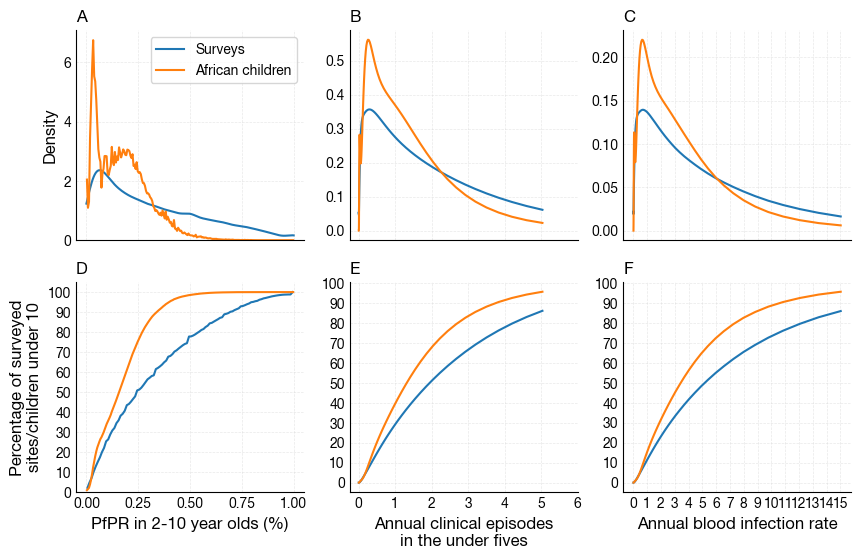

In [7]:
#| label: fig-distributions
#| fig-cap: "A) Distributions of *Pf*PR~2-10~ over survey sites (blue) and over African children under ten (orange). B) Inferred distributons of average annual clinical episodes in the under fives. C) Inferred distributions of blood infection rates. D-F) cumulative distributions of A-C. Early life protection and clinical immunity parameters are the posterior means of the homogeneous model fitted to the population-level data of Dielmo and Ndiop village, Senegal."

λs, clinical_rate_under_5 = infection_rate.infection_rate_vs_clinical_rate()
(_, trape_fit), data = infection_rate.model_pfpr_clinical_relationship(data)

dists = infection_rate.construct_distributions(map, count_mean_total_africa, trape_fit, clinical_rate_under_5, λs)
fig, axs = infection_rate.plot_distributions(dists, map, count_mean_total_africa)

# Sensitivity of blood infection rate distribution over African children under ten to changes in parameter values

[@fig-distribution_sensitivity] demonstrates the sensitivity of the distribution of blood infection rate distribution over African children under ten to changes in parameters $\rho_\text{elp}$, $\tau_\text{elp}$ and $\rho_\text{clinical}$. 

Changes in these parameters do not change the position of the distribution's peak, but they do broaden the distribution (top row of [@fig-distribution_sensitivity]). This changes how rapidly the cumulative distribution rises with increasing infection rate (bottom row). So, given a particular infection rate there is some uncertainty in how many African children under ten experience at most this infection rate. The degree of uncertainty depends on infection rate. But, overall, we can conclude that quantifying the distribution of blood infection rate across Africa is possible with reasonable precision.

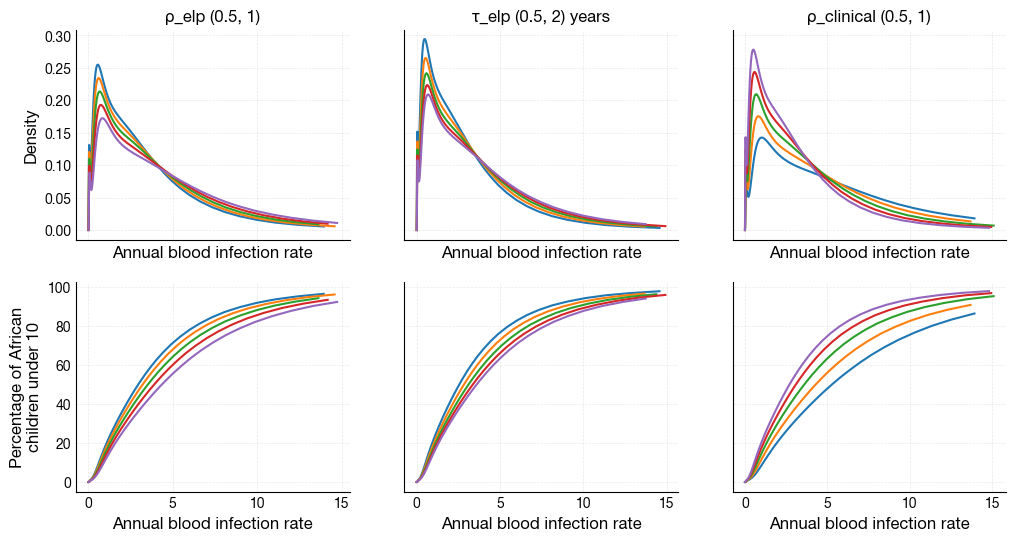

In [8]:
#| label: fig-distribution_sensitivity
#| fig-cap: "Sensitivity of A) distributions and B) cumulutive distributions of annual blood infection rate over African children under ten to changes in relative protection of newborns to infection, $\\rho_\\text{elp}$, half-life of early life protection, $\\tau_\\text{elp}$, and the risk of clinical malaria on first infection , $\\rho_\\text{clinical}$."

fig, axs = infection_rate.distribution_sensitivity(trape_fit, map, count_mean_total_africa)

# R21 deaths averted weighted by distribution of blood infection rate

Having quantified the distribution of infection rates across Africa, we can then ask, if all African children were vaccinated with R21 with one booster, how many deaths would be averted?

Assuming our default model parameters, we have plotted the lifetime number of deaths averted per 100,000 fully R21-vaccinated children with one booster in [@fig-weighted_deaths_averted]B. The problem for R21 is that, below a critical blood infection rate ($\lambda_\text{R21}$) of about 1.5 blood infections per year, averted deaths is negative because R21 slows infection rate, delaying the development of natural immunity causing more severe episodes in the over fives which have a higher mortality rate than at younger ages.

In [@fig-weighted_deaths_averted]C we calculate averted deaths weighted by the distribution of blood infection rate across Africa. The answer to the above question is the area under the curve in panel C. 

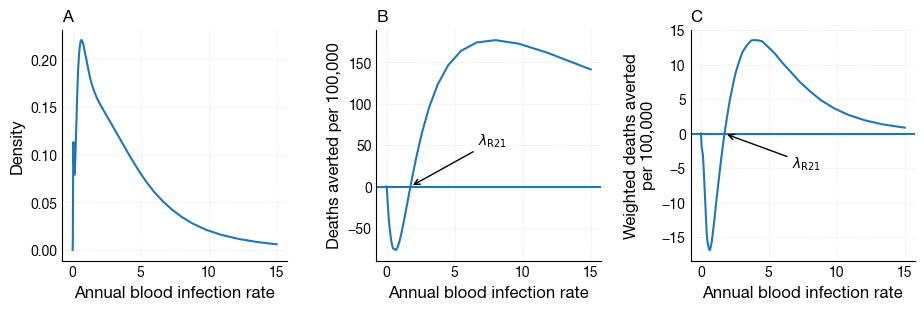

In [10]:
#| label: fig-weighted_deaths_averted
#| fig-cap: "A) Distribution of annual blood infection rate over African children under ten. B) Lifetime deaths averted per 100,000 fully R21-vaccinated children with one booster in a seasonal setting across blood infection rates for the default model parameters. C) Lifetime deaths averted weighted by the distribution of blood infection rate."

fig, axs = infection_rate.plot_weighted_averted_deaths(map, count_mean_total_africa)

The area under the curve can be decomposed into deaths indirectly caused by R21 and deaths directly averted by R21. In addition, we can also calculate the ratio of deaths averted to deaths caused by taking the ratio of the areas under the curves to the right and left of $\lambda_\text{R21}$ respectively.

These values are shown in [@fig-net_deaths] for different values of $\rho_\text{elp}$, $\tau_\text{elp}$, $\rho_\text{clinical}$ and $\epsilon_\text{severe}$ — the parameters that have the most effect on the distribution of blood infection rate and $\lambda_\text{R21}$ (see [Notebook S10](S10_sensitivity_analysis.ipynb)).

The results show that immunising every African child with R21 with one booster would avert around 60-70 deaths per 100,000 fully vaccinated children, and that this is insensitive to changes in model parameter values. For every death indirectly caused by R21, it will avert between about 4-10 deaths depending on particular parameter values.

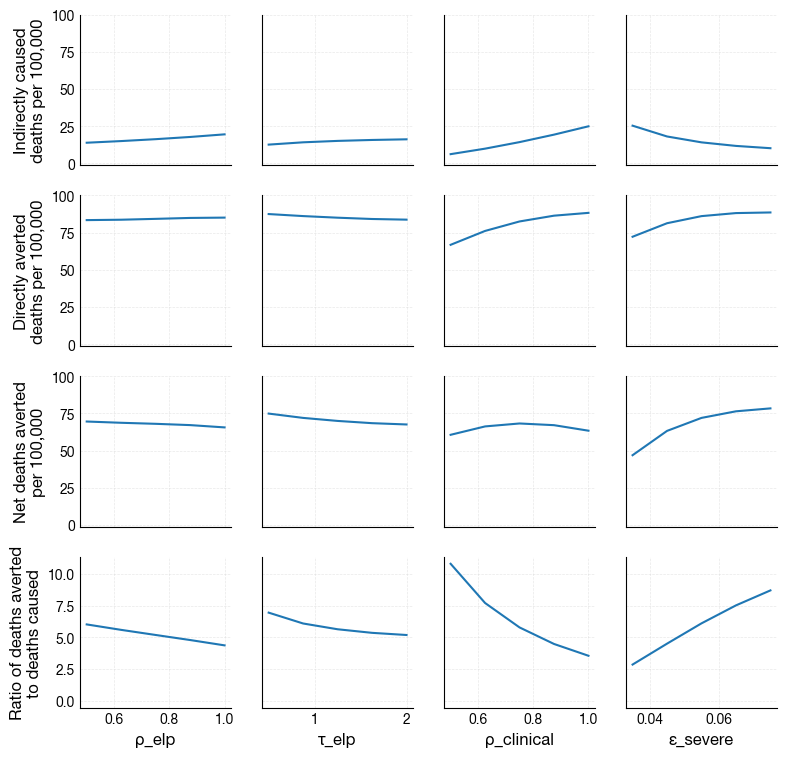

In [ ]:
#| label: fig-net_deaths
#| fig-cap: "Sensitivity of net averted deaths in 100,000 fully R21-vaccinated African children with one booster in a seasonal setting to changes in parameter values that have the most effect on the distribution of blood infection rate and $\lambda_\text{R21}$. Top row: Indirectly caused deaths per 100,000 (the area under the curve to the left of $\lambda_\text{R21}$ in [@fig-weighted_deaths_averted]C). Second row: Directly averted deaths (the area under the curve to the right of $\lambda_\text{R21}$). Third row: Net averted deaths. Fourth row: the ratio of directly averted deaths to indirectly caused deaths.   for illustrative parameter sets. "

# infection_rate.sensitivity_net_deaths(map, count_mean_total_africa)
fig, axs = infection_rate.plot_net_deaths()

::: {#refs}
:::